In [1]:
import numpy as np
import matplotlib.pyplot as plt

from binomial_tree.binomial_tree import BinomialTree
from neural_network.config import MarketParams
from black_scholes.bs import BlackScholes


In [2]:
n_assets = 1
S0 = 1.0
r = 0.1
sigma = 0.55
K = 1.0
T = 1

params = MarketParams(n_assets, S0, r, sigma, K, T)
american_tree = BinomialTree(params, n_steps=500, exercise_type="american")
european_tree = BinomialTree(params, n_steps=500, exercise_type="european")
black_scholes = BlackScholes(params, option_type="put")

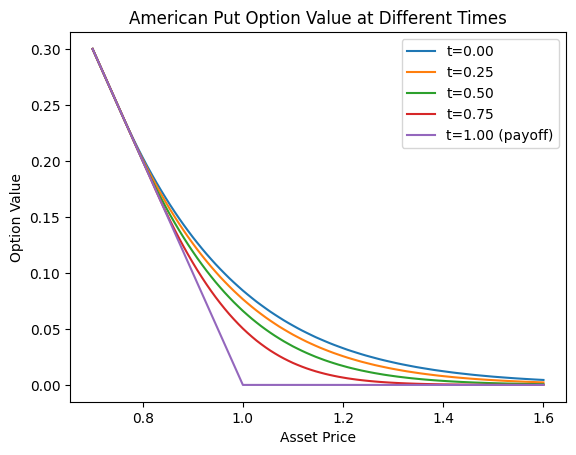

In [3]:
S = np.linspace(0.7, 1.6, 100)

ts = [0.0, 0.25, 0.5, 0.75]
for t in ts:
    V = american_tree.predict(t, S)
    plt.plot(S, V, label=f't={t:.2f}')
plt.plot(S, np.maximum(K - S, 0), label='t=1.00 (payoff)')
plt.title('American Put Option Value at Different Times')
plt.xlabel('Asset Price')
plt.ylabel('Option Value')
plt.legend()
plt.show()

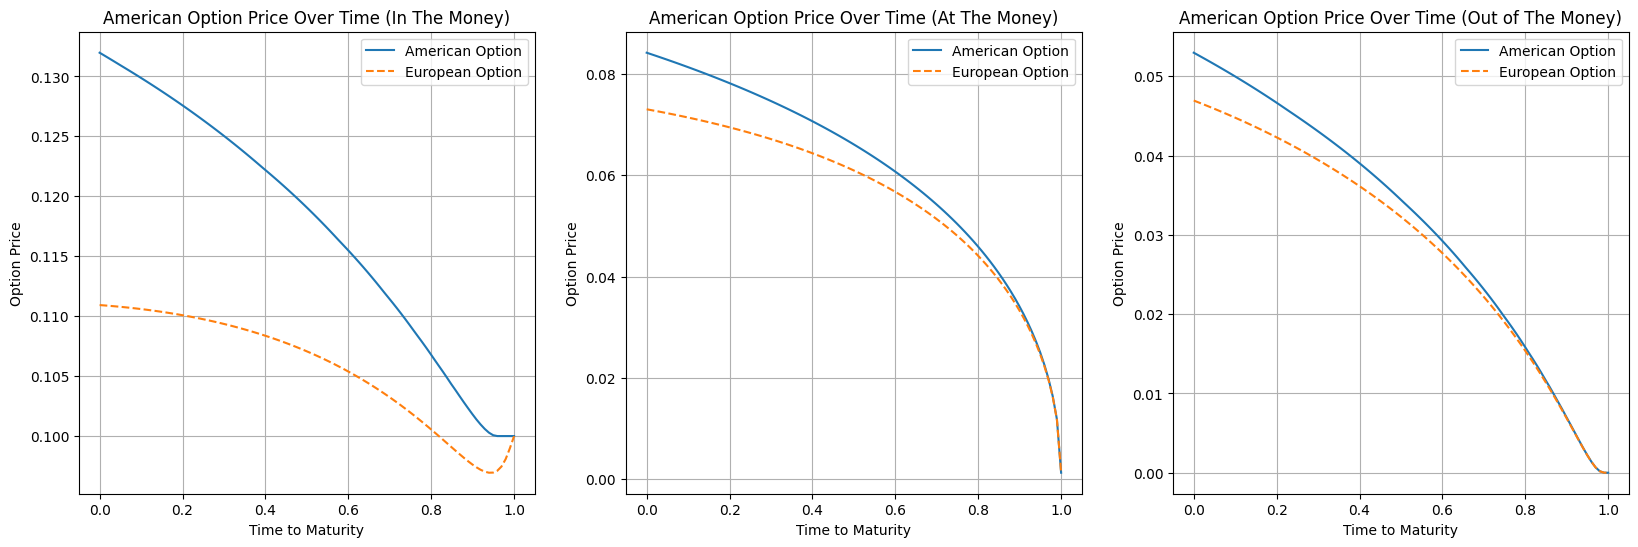

In [4]:
ts = np.linspace(0, T - 1e-4, 100)

S_itm = K * 0.9
S_atm = K
S_otm = K * 1.1

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
V_itm = [american_tree.predict(t, S_itm) for t in ts]
V_itm_eur = black_scholes.price(ts, S_itm).reshape(-1)
plt.plot(ts, V_itm, label='American Option')
plt.plot(ts, V_itm_eur, label='European Option', linestyle='--')
plt.title('American Option Price Over Time (In The Money)')
plt.xlabel('Time to Maturity')
plt.ylabel('Option Price')
plt.grid()
plt.legend()

plt.subplot(1, 3, 2)
V_atm = [american_tree.predict(t, S_atm) for t in ts]
V_atm_eur = [european_tree.predict(t, S_atm) for t in ts]
V_atm_eur = black_scholes.price(ts, S_atm).reshape(-1)

plt.plot(ts, V_atm, label='American Option')
plt.plot(ts, V_atm_eur, label='European Option', linestyle='--')
plt.title('American Option Price Over Time (At The Money)')
plt.xlabel('Time to Maturity')
plt.ylabel('Option Price')
plt.grid()
plt.legend()

plt.subplot(1, 3, 3)
V_otm = [american_tree.predict(t, S_otm) for t in ts]
V_otm_eur = [european_tree.predict(t, S_otm) for t in ts]
V_otm_eur = black_scholes.price(ts, S_otm).reshape(-1)
plt.plot(ts, V_otm, label='American Option')
plt.plot(ts, V_otm_eur, label='European Option', linestyle='--')
plt.title('American Option Price Over Time (Out of The Money)')
plt.xlabel('Time to Maturity')
plt.ylabel('Option Price')
plt.grid()
plt.legend()

plt.show()